In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
data = pd.read_csv("noisy_curvefit_data.csv")

In [7]:
data.shape
# There are 100 rows and 6 columns

(100, 6)

In [8]:
data.head

<bound method NDFrame.head of            x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0  -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1  -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2  -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3  -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4  -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
..       ...        ...        ...        ...        ...        ...
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850

[100 rows x 6 columns]>

In [10]:
data.tail

<bound method NDFrame.tail of            x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0  -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1  -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2  -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3  -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4  -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
..       ...        ...        ...        ...        ...        ...
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850

[100 rows x 6 columns]>

In [11]:
data.columns

Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')

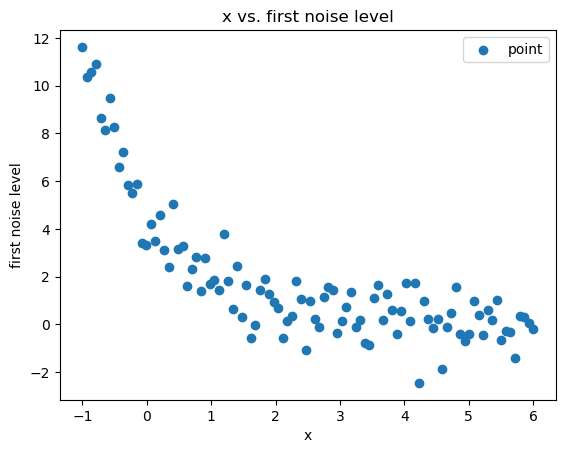

In [8]:
plt.scatter(data['x'], data['y_noise_1'])
plt.xlabel('x')
plt.ylabel('first noise level')
plt.title('x vs. first noise level')
plt.legend(['point'])
plt.show()

In [9]:
def model(x, A, k):
    return A * np.exp(-k*x)

In [14]:
p0 = [1,1]
popt, pcov = curve_fit(model, data['x'], data['y_noise_1'], p0=p0)

A_fit, k_fit = popt

print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

residuals = data['y_noise_1'] - model(data['x'], A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(data['x']) - len(popt)
chi2_reduced = chi2 / dof

Fit: y = 4.71 * e^(-0.92 * x)


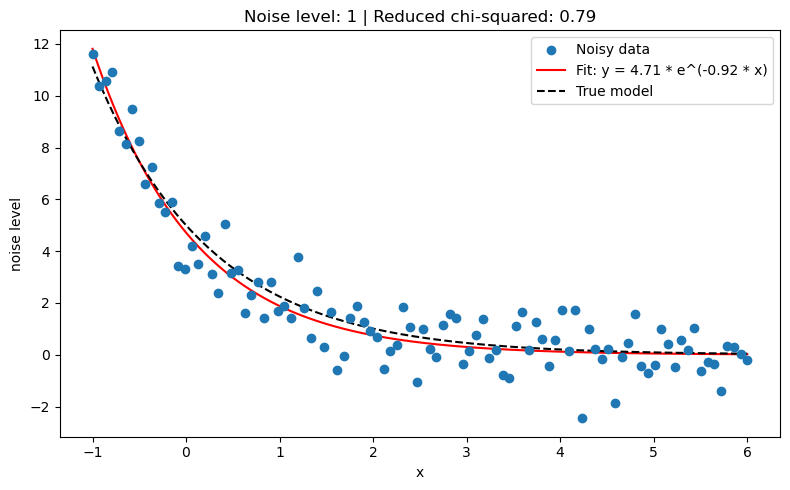

In [18]:
x_fit = np.linspace(min(data['x']), max(data['x']), 500)

plt.figure(figsize=(8, 5))
plt.scatter(data['x'], data['y_noise_1'], label='Noisy data', zorder=3)
plt.plot(x_fit, model(x_fit, A_fit, k_fit), color='red', label=f'Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)')
plt.plot(x_fit, model(x_fit, 5, 0.8), color='black', linestyle='--', label='True model')
plt.title(f'Noise level: 1 | Reduced chi-squared: {chi2_reduced:.2f}')
plt.xlabel('x')
plt.ylabel('noise level')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    
    return A_fit, k_fit, chi2_reduced

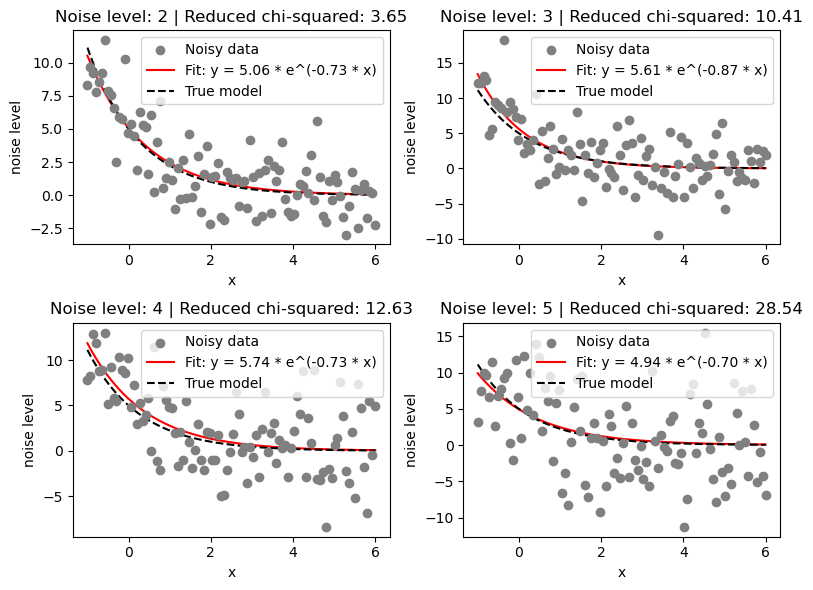

In [26]:
noise_data = [data['y_noise_2'], data['y_noise_3'], data['y_noise_4'], data['y_noise_5']]
noise_levels = [2, 3, 4, 5]

fig, axes = plt.subplots(2, 2, figsize = (8,6))
axes = axes.flatten()

x_fit = np.linspace(min(data['x']), max(data['x']), 500)

for i, (y_noise, noise_level) in enumerate(zip(noise_data, noise_levels)):
    A_fit, k_fit, chi2_reduced = fit_model(data['x'], y_noise)
    
    ax = axes[i]
    ax.scatter(data['x'], y_noise, color='gray', label='Noisy data', zorder=3)
    ax.plot(x_fit, model(x_fit, A_fit, k_fit), color='red', label=f'Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)')
    ax.plot(x_fit, model(x_fit, 5, 0.8), color='black', linestyle='--', label='True model')
    ax.set_title(f'Noise level: {noise_level} | Reduced chi-squared: {chi2_reduced:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('noise level')
    ax.legend()

plt.tight_layout()
plt.show()

As you increase the nosie level, the red and black lines fit the data increasingly worse. The reduced chi-squared increases, indicating a poor fit to the data as the noise level increases.

In [28]:
noise_data = [data['y_noise_1'], data['y_noise_2'], data['y_noise_3'], data['y_noise_4'], data['y_noise_5']]
noise_levels = [1, 2, 3, 4, 5]

results = []
for y_noise, noise_level in zip(noise_data, noise_levels):
    A_fit, k_fit, chi2_reduced = fit_model(data['x'], y_noise)
    results.append({
        'Noise Level': noise_level,
        'A_fit': A_fit,
        'k_fit': k_fit,
        'Reduced Chi-Squared': chi2_reduced
    })

df = pd.DataFrame(results)
print(df)

   Noise Level     A_fit     k_fit  Reduced Chi-Squared
0            1  4.714814  0.918308             0.790673
1            2  5.063889  0.730396             3.649382
2            3  5.609396  0.870372            10.410207
3            4  5.738727  0.725965            12.626832
4            5  4.943458  0.695012            28.538124


In [30]:
df.to_csv('noisy_parameters.csv', index = False)